# Лабораторная работа №3

In [7]:
import os
import subprocess
import numpy as np
import time
import matplotlib.pyplot as plt

def load_matrix(filename, size):
    if not os.path.isfile(filename):
        raise FileNotFoundError(f"Матрица не найдена: {filename}")
    return np.loadtxt(filename, dtype=int).reshape((size, size))

def verify_multiplication(A_file, B_file, C_file, size):
    A = load_matrix(A_file, size)
    B = load_matrix(B_file, size)
    C_computed = load_matrix(C_file, size)
    C_expected = np.dot(A, B)
    
    if np.array_equal(C_computed, C_expected):
        print(f"✅ Верификация успешна для {size}x{size}")
    else:
        print(f"❌ Ошибка верификации для {size}x{size}")

def run_mpi_test(size, num_procs, exe_path="matrix_mult_mpi.exe"):
    A_file = f"data/{size}/matrix_A.txt"
    B_file = f"data/{size}/matrix_B.txt"
    C_file = f"data/{size}/matrix_C.txt"
    
    if not os.path.isfile(exe_path):
        raise FileNotFoundError(f"Не найден MPI-исполняемый файл: {exe_path}")
    
    cmd = [
        "mpiexec", "-n", str(num_procs),
        exe_path, str(size), A_file, B_file, C_file
    ]
    print(f"\n▶ Запуск MPI: size={size}, procs={num_procs}")
    t0 = time.time()
    subprocess.run(cmd, check=True)
    elapsed = time.time() - t0
    print(f"⏱ Время: {elapsed:.4f} сек")
    
    verify_multiplication(A_file, B_file, C_file, size)
    return (size, elapsed)

def plot_results(results):
    plt.figure(figsize=(8, 6))
    for procs, data in results.items():
        sizes, times = zip(*data)
        plt.plot(sizes, times, marker='o', label=f"{procs} proc")
    plt.xlabel("Размер матрицы N")
    plt.ylabel("Время, сек")
    plt.title("MPI: время умножения матриц")
    plt.grid(True)
    plt.legend(title="Процессов")
    plt.tight_layout()
    plt.show()


In [8]:
sizes = [10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
exe_path = "matrix_mult/matrix_mult/x64/Debug/matrix_mult.exe"
results  = {}

# === Тестирование с 1 процессом ===
procs = 1
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


▶ Запуск MPI: size=10, procs=1
⏱ Время: 0.2082 сек
✅ Верификация успешна для 10x10

▶ Запуск MPI: size=100, procs=1
⏱ Время: 0.2645 сек
✅ Верификация успешна для 100x100

▶ Запуск MPI: size=200, procs=1
⏱ Время: 0.6341 сек
✅ Верификация успешна для 200x200

▶ Запуск MPI: size=300, procs=1
⏱ Время: 1.4768 сек
✅ Верификация успешна для 300x300

▶ Запуск MPI: size=400, procs=1
⏱ Время: 2.9581 сек
✅ Верификация успешна для 400x400

▶ Запуск MPI: size=500, procs=1
⏱ Время: 5.3419 сек
✅ Верификация успешна для 500x500

▶ Запуск MPI: size=600, procs=1
⏱ Время: 8.5538 сек
✅ Верификация успешна для 600x600

▶ Запуск MPI: size=700, procs=1
⏱ Время: 13.1067 сек
✅ Верификация успешна для 700x700

▶ Запуск MPI: size=800, procs=1
⏱ Время: 19.1263 сек
✅ Верификация успешна для 800x800

▶ Запуск MPI: size=900, procs=1
⏱ Время: 26.5753 сек
✅ Верификация успешна для 900x900

▶ Запуск MPI: size=1000, procs=1
⏱ Время: 39.5200 сек
✅ Верификация успешна для 1000x1000


In [9]:
procs = 2
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


▶ Запуск MPI: size=10, procs=2
⏱ Время: 0.2123 сек
✅ Верификация успешна для 10x10

▶ Запуск MPI: size=100, procs=2
⏱ Время: 0.2736 сек
✅ Верификация успешна для 100x100

▶ Запуск MPI: size=200, procs=2
⏱ Время: 0.5281 сек
✅ Верификация успешна для 200x200

▶ Запуск MPI: size=300, procs=2
⏱ Время: 1.1315 сек
✅ Верификация успешна для 300x300

▶ Запуск MPI: size=400, procs=2
⏱ Время: 2.1254 сек
✅ Верификация успешна для 400x400

▶ Запуск MPI: size=500, procs=2
⏱ Время: 3.7187 сек
✅ Верификация успешна для 500x500

▶ Запуск MPI: size=600, procs=2
⏱ Время: 5.6960 сек
✅ Верификация успешна для 600x600

▶ Запуск MPI: size=700, procs=2
⏱ Время: 8.6183 сек
✅ Верификация успешна для 700x700

▶ Запуск MPI: size=800, procs=2
⏱ Время: 11.9077 сек
✅ Верификация успешна для 800x800

▶ Запуск MPI: size=900, procs=2
⏱ Время: 16.3702 сек
✅ Верификация успешна для 900x900

▶ Запуск MPI: size=1000, procs=2
⏱ Время: 23.3405 сек
✅ Верификация успешна для 1000x1000


In [10]:
procs = 4
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


▶ Запуск MPI: size=10, procs=4
⏱ Время: 0.2316 сек
✅ Верификация успешна для 10x10

▶ Запуск MPI: size=100, procs=4
⏱ Время: 0.2956 сек
✅ Верификация успешна для 100x100

▶ Запуск MPI: size=200, procs=4
⏱ Время: 0.5259 сек
✅ Верификация успешна для 200x200

▶ Запуск MPI: size=300, procs=4
⏱ Время: 0.9925 сек
✅ Верификация успешна для 300x300

▶ Запуск MPI: size=400, procs=4
⏱ Время: 1.7540 сек
✅ Верификация успешна для 400x400

▶ Запуск MPI: size=500, procs=4
⏱ Время: 2.9506 сек
✅ Верификация успешна для 500x500

▶ Запуск MPI: size=600, procs=4
⏱ Время: 4.3098 сек
✅ Верификация успешна для 600x600

▶ Запуск MPI: size=700, procs=4
⏱ Время: 6.0831 сек
✅ Верификация успешна для 700x700

▶ Запуск MPI: size=800, procs=4
⏱ Время: 8.3356 сек
✅ Верификация успешна для 800x800

▶ Запуск MPI: size=900, procs=4
⏱ Время: 11.2542 сек
✅ Верификация успешна для 900x900

▶ Запуск MPI: size=1000, procs=4
⏱ Время: 15.5256 сек
✅ Верификация успешна для 1000x1000


In [11]:
procs = 8
res   = []
for size in sizes:
    res.append(run_mpi_test(size, procs, exe_path=exe_path))
results[procs] = res


▶ Запуск MPI: size=10, procs=8
⏱ Время: 0.3641 сек
✅ Верификация успешна для 10x10

▶ Запуск MPI: size=100, procs=8
⏱ Время: 0.3403 сек
✅ Верификация успешна для 100x100

▶ Запуск MPI: size=200, procs=8
⏱ Время: 0.5905 сек
✅ Верификация успешна для 200x200

▶ Запуск MPI: size=300, procs=8
⏱ Время: 1.0138 сек
✅ Верификация успешна для 300x300

▶ Запуск MPI: size=400, procs=8
⏱ Время: 1.7296 сек
✅ Верификация успешна для 400x400

▶ Запуск MPI: size=500, procs=8
⏱ Время: 2.6642 сек
✅ Верификация успешна для 500x500

▶ Запуск MPI: size=600, procs=8
⏱ Время: 3.9500 сек
✅ Верификация успешна для 600x600

▶ Запуск MPI: size=700, procs=8
⏱ Время: 5.5136 сек
✅ Верификация успешна для 700x700

▶ Запуск MPI: size=800, procs=8
⏱ Время: 7.5828 сек
✅ Верификация успешна для 800x800

▶ Запуск MPI: size=900, procs=8
⏱ Время: 9.6311 сек
✅ Верификация успешна для 900x900

▶ Запуск MPI: size=1000, procs=8
⏱ Время: 12.7488 сек
✅ Верификация успешна для 1000x1000


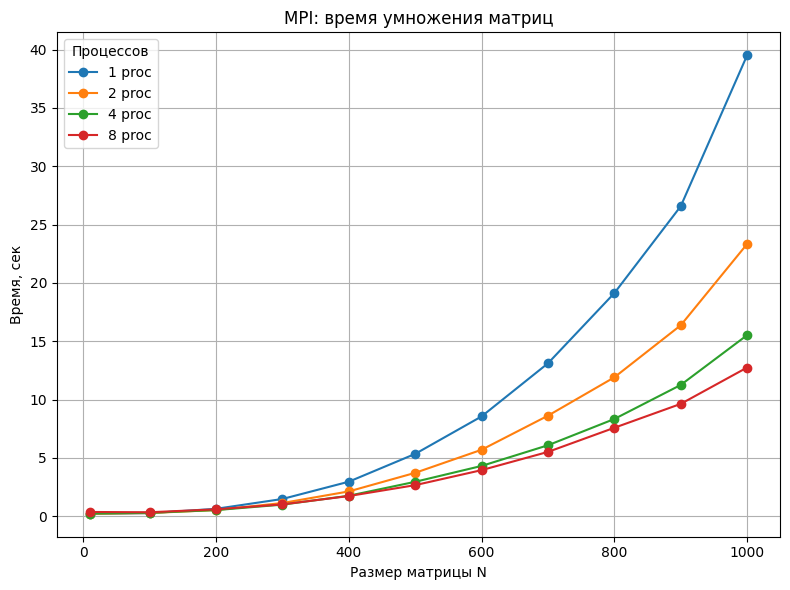

In [12]:
plot_results(results)
